In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
!pip install xgboost

In [44]:
new_df1=pd.read_csv("Telecom_Customer_Churn.csv")

In [45]:
new_df1.head()

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly GB Download,Monthly Charge,Total Charges,Churn_Binary,Security Services,Gender_Male,Married_Yes,Offer_Offer A,Offer_Offer B,Offer_Offer C,Offer_Offer D,Offer_Offer E,Multiple Lines_Yes,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No Internet Service,Streaming TV_No Internet Service,Streaming TV_Yes,Streaming Movies_No Internet Service,Streaming Movies_Yes,Streaming Music_No Internet Service,Streaming Music_Yes,Unlimited Data_No Internet Service,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
0,37,0,2,9,16.0,65.6,593.30,0,2,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,1,0
1,46,0,0,9,10.0,-4.0,542.40,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
2,50,0,0,4,30.0,73.9,280.85,1,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0
3,78,0,1,13,4.0,98.0,1237.85,1,2,1,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0
4,75,0,3,3,11.0,83.9,267.40,1,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1,0


In [46]:
new_df1.head()

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly GB Download,Monthly Charge,Total Charges,Churn_Binary,Security Services,Gender_Male,Married_Yes,Offer_Offer A,Offer_Offer B,Offer_Offer C,Offer_Offer D,Offer_Offer E,Multiple Lines_Yes,Internet Type_DSL,Internet Type_Fiber Optic,Internet Type_No Internet Service,Streaming TV_No Internet Service,Streaming TV_Yes,Streaming Movies_No Internet Service,Streaming Movies_Yes,Streaming Music_No Internet Service,Streaming Music_Yes,Unlimited Data_No Internet Service,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
0,37,0,2,9,16.0,65.6,593.30,0,2,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,1,0
1,46,0,0,9,10.0,-4.0,542.40,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0
2,50,0,0,4,30.0,73.9,280.85,1,1,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0
3,78,0,1,13,4.0,98.0,1237.85,1,2,1,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0,1,0,0
4,75,0,3,3,11.0,83.9,267.40,1,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1,0


In [47]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X = new_df1.drop("Churn_Binary", axis=1)
y = new_df1["Churn_Binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
# Standard Scaling (Only for Logistic Regression)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": (LogisticRegression(random_state=42), True),
    "Decision Tree": (DecisionTreeClassifier(random_state=42), False),
    "Random Forest": (RandomForestClassifier(random_state=42), False),
    "XGBoost": (
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ),
        False
    )
}

Logistic Regression
Accuracy : 0.8194
Precision: 0.6355
Recall   : 0.8529
F1 Score : 0.7283
ROC-AUC  : 0.9104


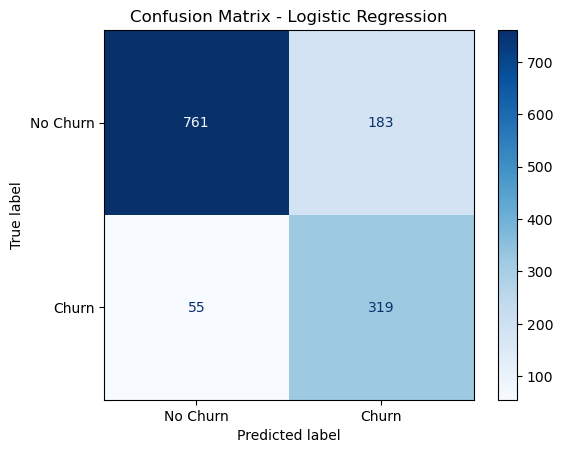

Decision Tree
Accuracy : 0.8088
Precision: 0.6548
Recall   : 0.6898
F1 Score : 0.6719
ROC-AUC  : 0.7729


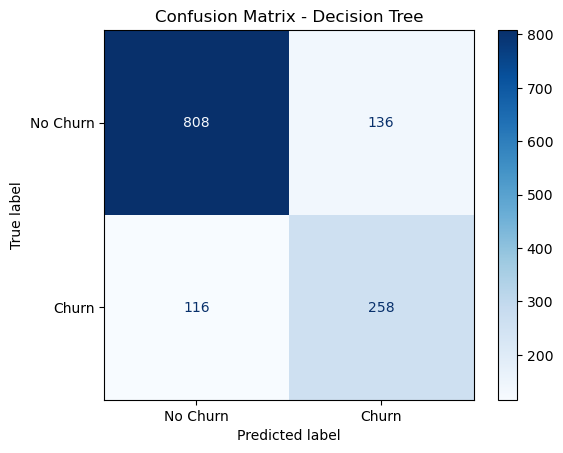

Random Forest
Accuracy : 0.8483
Precision: 0.7242
Recall   : 0.7513
F1 Score : 0.7375
ROC-AUC  : 0.9163


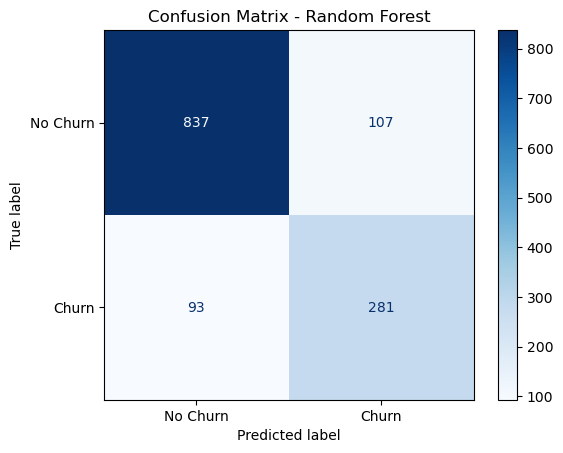

XGBoost
Accuracy : 0.8422
Precision: 0.7255
Recall   : 0.7139
F1 Score : 0.7197
ROC-AUC  : 0.9135


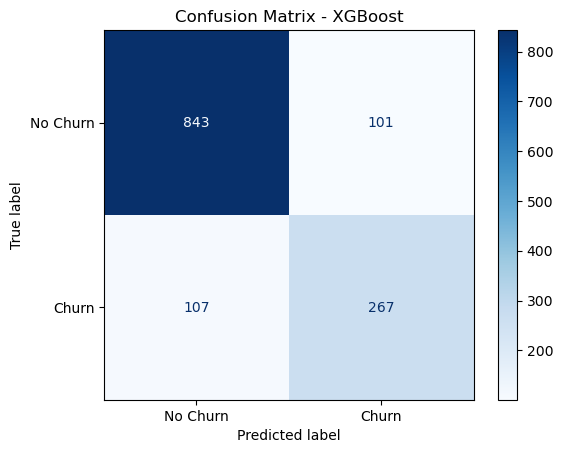

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

results = []

for name, (model, scale) in models.items():

    # Selecting scaled or unscaled data
    if scale:
        Xtr = X_train_scaled
        Xte = X_test_scaled
    else:
        Xtr = X_train
        Xte = X_test

    # SMOTE only on training data
    smote = SMOTE(random_state=42)
    Xtr_smote, y_train_smote = smote.fit_resample(Xtr, y_train)

    # Train
    model.fit(Xtr_smote, y_train_smote)

    # Predictions
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()

In [28]:
# Comparison Table

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.848255,0.724227,0.751337,0.737533,0.916312
3,XGBoost,0.842185,0.725543,0.713904,0.719677,0.913492
0,Logistic Regression,0.819423,0.635458,0.852941,0.728311,0.910408
1,Decision Tree,0.808801,0.654822,0.689840,0.671875,0.772886


In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(Xtr_smote, y_train_smote)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score :", rf_grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score : 0.8983752569482505


In [30]:
from xgboost import XGBClassifier

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=xgb_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

xgb_grid.fit(Xtr_smote, y_train_smote)

print("Best Parameters:", xgb_grid.best_params_)
print("Best CV Score :", xgb_grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score : 0.8973374137447774


In [31]:
best_rf = rf_grid.best_estimator_

y_pred = best_rf.predict(X_test)

In [32]:
best_xgb = xgb_grid.best_estimator_

y_pred = best_xgb.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

tuned_results = []

models = {
    "Random Forest": (rf_grid.best_estimator_, X_test),
    "XGBoost": (xgb_grid.best_estimator_, X_test)
}

for name, (model, Xte) in models.items():

    y_pred = model.predict(Xte)

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

pd.DataFrame(tuned_results).sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,XGBoost,0.858877,0.751337,0.751337,0.751337
0,Random Forest,0.852807,0.738095,0.745989,0.742021


Accuracy : 0.858877086494689
Precision: 0.7513368983957219
Recall   : 0.7513368983957219
F1 Score : 0.7513368983957219
ROC-AUC  : 0.9195425088371251


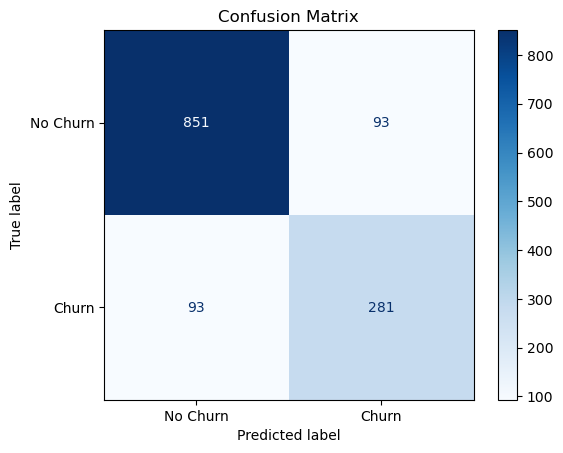

In [34]:
# Best tuned model
best_model = xgb_grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [35]:
# Create DataFrame of feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20 features
print(feature_importance.head(20))

                              Feature  Importance
28                  Contract_Two Year    0.280611
27                  Contract_One Year    0.190169
30         Payment Method_Credit Card    0.060140
1                Number of Dependents    0.051978
3                    Tenure in Months    0.049820
2                 Number of Referrals    0.047615
18  Internet Type_No Internet Service    0.033512
16                  Internet Type_DSL    0.027091
11                      Offer_Offer B    0.021124
9                         Married_Yes    0.020702
5                      Monthly Charge    0.018161
7                   Security Services    0.018016
13                      Offer_Offer D    0.016315
17          Internet Type_Fiber Optic    0.016042
22               Streaming Movies_Yes    0.014891
8                         Gender_Male    0.014544
24                Streaming Music_Yes    0.014037
26                 Unlimited Data_Yes    0.012065
0                                 Age    0.011448


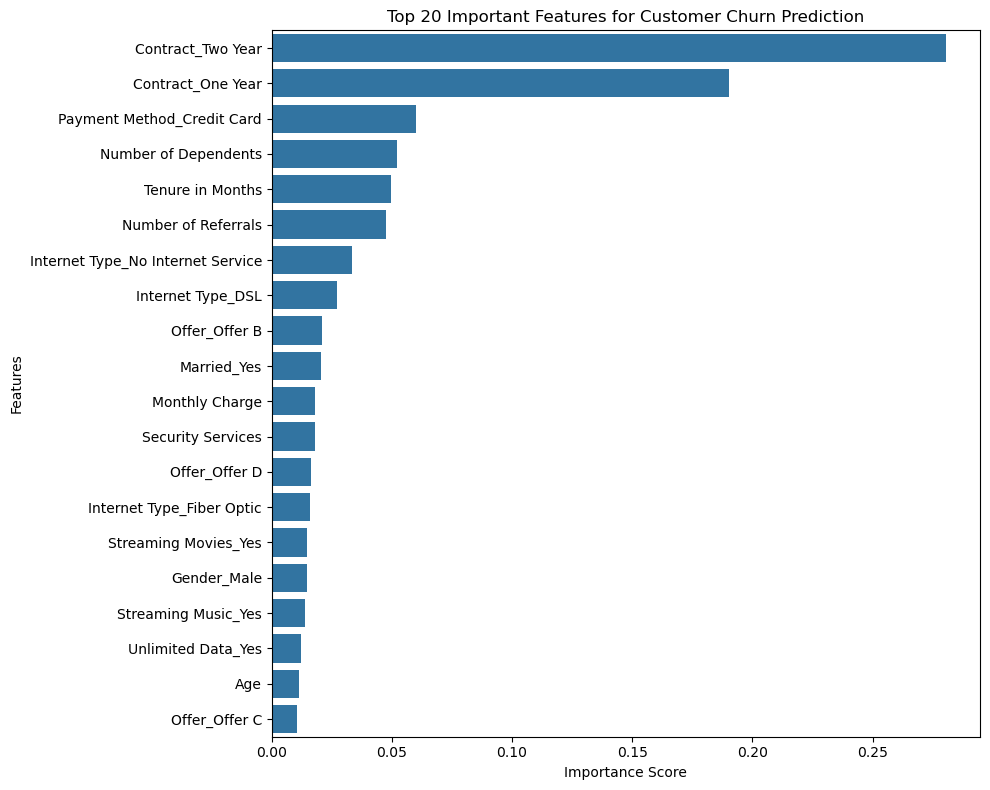

In [36]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features for Customer Churn Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [37]:
import joblib
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")
joblib.dump(xgb_grid.best_estimator_, "churn_project_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [38]:
print(X.columns.tolist())

['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Security Services', 'Gender_Male', 'Married_Yes', 'Offer_Offer A', 'Offer_Offer B', 'Offer_Offer C', 'Offer_Offer D', 'Offer_Offer E', 'Multiple Lines_Yes', 'Internet Type_DSL', 'Internet Type_Fiber Optic', 'Internet Type_No Internet Service', 'Streaming TV_No Internet Service', 'Streaming TV_Yes', 'Streaming Movies_No Internet Service', 'Streaming Movies_Yes', 'Streaming Music_No Internet Service', 'Streaming Music_Yes', 'Unlimited Data_No Internet Service', 'Unlimited Data_Yes', 'Contract_One Year', 'Contract_Two Year', 'Paperless Billing_Yes', 'Payment Method_Credit Card', 'Payment Method_Mailed Check']
